In [ ]:
from torch.utils.data import Dataset, DataLoader
import json

class DuReaderQG(Dataset):
    def __init__(self, data_file):
        super().__init__()
        self.data = self.load_data(data_file)

    def load_data(self, data_file):
        data_res = {}
        with open(data_file, "rt") as f:
            for index, line in enumerate(f):
                sample = json.loads(line.strip())
                data_res[index] = sample

        return data_res
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_data = DuReaderQG("data/DuReaderQG/train.json")
valid_data = DuReaderQG("data/DuReaderQG/dev.json")

print(train_data.__getitem__(0))

{'context': '第35集雪见缓缓张开眼睛，景天又惊又喜之际，长卿和紫萱的仙船驶至，见众人无恙，也十分高兴。众人登船，用尽合力把自身的真气和水分输给她。雪见终于醒过来了，但却一脸木然，全无反应。众人向常胤求助，却发现人世界竟没有雪见的身世纪录。长卿询问清微的身世，清微语带双关说一切上了天界便有答案。长卿驾驶仙船，众人决定立马动身，往天界而去。众人来到一荒山，长卿指出，魔界和天界相连。由魔界进入通过神魔之井，便可登天。众人至魔界入口，仿若一黑色的蝙蝠洞，但始终无法进入。后来花楹发现只要有翅膀便能飞入。于是景天等人打下许多乌鸦，模仿重楼的翅膀，制作数对翅膀状巨物。刚佩戴在身，便被吸入洞口。众人摔落在地，抬头发现魔界守卫。景天和众魔套交情，自称和魔尊重楼相熟，众魔不理，打了起来。', 'answer': '第35集', 'question': '仙剑奇侠传3第几集上天界', 'id': 0}


In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("./model/langboat/mengzi-t5-base")

def collate_fn(batch):
    
    questions = [item['question'] for item in batch]
    contexts = [item['context'] for item in batch]
    answers = [item['answer'] for item in batch]

    # 批量编码输入
    inputs = tokenizer(
        [f"question: {q} context: {c}" for q, c in zip(questions, contexts)],
        padding=True,          # 动态补齐到本 Batch 最长
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    
    # 批量编码标签
    labels = tokenizer(
        answers,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    # T5 规范：将 padding token 的标签设置为 -100，计算 Loss 时会自动忽略？？？
    labels[labels == tokenizer.pad_token_id] = -100

    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": labels["input_ids"]
    }


In [ ]:
# train_dataset = DuReaderQG("data/DuReaderQG/train.json")
# train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

res = next(iter(train_loader))
print('batch_input_ids shape:', len(res["input_ids"]))
# print('batch_labels shape:', labels.shape)
print(res["input_ids"][0])
# print(attention_mask)
# print(labels)

batch_input_ids shape: 4
tensor([ 3454,  2055, 21293, 15807,    13,     7,    21,  4650, 14358,  6923,
            7, 25395,  7368,  1733,  1550,    13,     7,    21,  4650,  5323,
            9,   787,  6796, 19904, 13464,     3,   354,  3818,     3,    21,
         4650, 14358,  6923,   297,  2838,   114,  1258,   614,     3,  1547,
         5436,  2490,  5621, 15897,   971,    13,  3121,   146,   985,    22,
          817,   614,  1177,    25,     3, 13482,    11,    21,  4650,   145,
        14826,   201,  1041,  1350,  2100,   971,     3,   250,     3,   107,
           45,   897,  3878,   787,  1125,    26,  3178, 26024,   436,    22,
          817,   114,  1336,   614,    25,     3,   315,    21,  4650, 13906,
         8400,   436,     3,    72, 18494,   123,  4650,    56,   487, 11788,
         2190,   498,  2710,  1031,     3,   107, 18333,     5, 15118,   156,
         5531,    26,  6912, 11208,   436,    22,  2117,   614,   407,    25,
            3, 13482,   123,  4650,    

In [ ]:
from tqdm.auto import tqdm
import torch

def train_loop(train_loader, model, optimizer, lr_scheduler, epoch, epochs, device):

    # 带有动态进度条的可迭代对象
    loop = tqdm(train_loader, leave = True)
    loop.set_description(f"Training Epoch [{epoch+1}/{epochs}]")
    total_loss = 0

    model.train()
    for batch_idx, batch in enumerate(loop):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
 
        output = model(input_ids = input_ids,
                     attention_mask = attention_mask,
                     labels = labels)
        loss = output.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()
        avg_loss = total_loss / (batch_idx + 1)

        loop.set_postfix(avg_loss=f"{avg_loss:.4f}")
    
    return avg_loss


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def valid_loop(dataloader, model, epoch, epochs, device):
  
    all_preds = []   # 存储所有预测答案的字符列表
    all_refs = []    # 存储所有标准答案的字符列表（嵌套结构）
    total_loss = 0

    loop = tqdm(dataloader, leave = True)
    loop.set_description(f"Testing Epoch [{epoch+1}/{epochs}]")

    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(loop):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # 模型生成
            outputs = model.generate(input_ids = input_ids,
                                    attention_mask = attention_mask,
                                    max_length=64)
            # 解码为字符串文本
            pred_texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)

            # 处理标准答案 (Labels)
            # 注意：需排除掉为了 padding 而设置的 -100
            label_ids = batch["labels"].cpu().numpy()
            label_ids = [[t for t in label if t != -100] for label in label_ids]
            ref_texts = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

            # --- 核心步骤：转换为 corpus_bleu 要求的格式 ---
            for pred, ref in zip(pred_texts, ref_texts):
                # 将字符串转为字符列表，例如 "12月" -> ["1", "2", "月"]
                pred_list = list(pred)
                ref_list = [list(ref)] # 每一个参考答案必须再包一层列表
                
                all_preds.append(pred_list)
                all_refs.append(ref_list)

            #计算 Loss (用于画曲线)
            outputs_for_loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs_for_loss.loss.item()

            avg_loss = total_loss / (batch_idx + 1)
            loop.set_postfix(avg_loss=f"{avg_loss:.4f}")

        # 2. 循环结束后，统一计算各个维度的 BLEU
        smoothing = SmoothingFunction().method1 #  使用平滑函数防止n-gram为0时分数为0
        
        # 定义不同维度的权重
        weights_list = {
            "BLEU-1": (1, 0, 0, 0),
            "BLEU-2": (0.5, 0.5, 0, 0),
            "BLEU-3": (0.33, 0.33, 0.33, 0),
            "BLEU-4": (0.25, 0.25, 0.25, 0.25)
        }

        bleu_res = {}
        for name, weights in weights_list.items():
            score = corpus_bleu(all_refs, all_preds, weights=weights, smoothing_function=smoothing)
            bleu_res[name] = score

        return avg_loss, bleu_res


In [ ]:
from torch.optim import AdamW
from transformers import get_scheduler
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

training_loss_res, validation_loss_res = [],[]
train_dataset = DuReaderQG("data/DuReaderQG/train.json")
valid_data = DuReaderQG("data/DuReaderQG/dev.json")
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, collate_fn = collate_fn)
valid_loader = DataLoader(valid_data, batch_size = 64, shuffle = False, collate_fn = collate_fn)

model = T5ForConditionalGeneration.from_pretrained("./model/langboat/mengzi-t5-base").to(device)

epochs = 5
lr = 3e-5
optimizer = AdamW(model.parameters(), lr = lr, weight_decay = 0.01)
lr_scheduler = get_scheduler(
    name = "linear",
    optimizer = optimizer,
    warmup_ratio = 0.1,
    num_training_steps = epochs * len(train_loader)
)

best_score = 0

for epoch in range(epochs):
    training_loss = train_loop(train_loader, model, optimizer, lr_scheduler, epoch, epochs, device)
    training_loss_res.append(training_loss)
    validation_loss, bleu_res = valid_loop(valid_loader, model, epoch, epochs, device)
    validation_loss_res.append(validation_loss)
    print("="*30)
    print(f"模型评估-Epoch {epoch + 1}:")
    for name, score in bleu_res.items():
        print(f"{name}: {score:.4f}")
    print("="*30) 

    # 保存模型
    if bleu_res["BLEU-4"] > best_score:
        best_score = bleu_res["BLEU-4"]
        output_dir = f"./checkpoints/epoch_{epoch+1}_valid_bleu_4:{best_score:.4f}_model"
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)


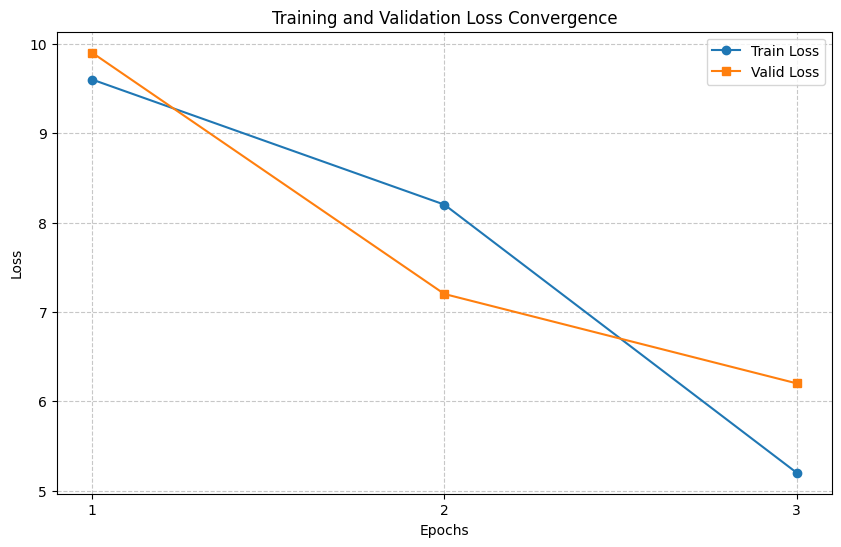

In [ ]:
import matplotlib.pyplot as plt

def plot_convergence(train_losses, val_losses):
    plt.figure(figsize=(10, 6))  
    # 绘制曲线
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Valid Loss', marker='s')
    # 图表装饰
    plt.title('Training and Validation Loss Convergence')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(range(1, len(train_losses) + 1)) # 确保横坐标显示整数 Epoch
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    # 保存或显示
    # plt.savefig('convergence_curve.png')
    plt.show()

# training_loss_res = [9.6,8.2,5.2]
# validation_loss_res = [9.9,7.2,6.2]
# 调用绘图函数
plot_convergence(training_loss_res, validation_loss_res)

In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

def predict_answer(context, query, model_path, device):
    """
    给定 context 和 query，生成对应答案
    :param context: 参考文章内容
    :param query: 提问的问题
    :param model_path: 训练好的模型权重路径
    :return: 模型生成的答案字符串
    """
    # 1. 自动选择运行设备 (GPU 或 CPU)
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 2. 加载训练好的 Tokenizer 和模型
    # 注意：这里加载的是你训练并保存后的 checkpoint 文件夹
    tokenizer = T5Tokenizer.from_pretrained(model_path)
    model = T5ForConditionalGeneration.from_pretrained(model_path).to(device)
    
    # 将模型设置为评估模式（关闭 Dropout 等）
    model.eval()

    # 3. 按照训练时的格式拼接输入文本
    # T5 格式：question: [问题] context: [文章]
    input_text = f"question: {query} context: {context}"

    # 4. 文本编码
    # padding 和 truncation 确保长度符合模型要求
    inputs = tokenizer.encode_plus(
        input_text,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).to(device)

    # 5. 模型生成 (推理)
    # 使用 Beam Search (束搜索) 提高生成质量，num_beams=4 是常用配置
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=64,       # 答案的最大长度
            num_beams=4,         # 使用束搜索
            early_stopping=True  # 生成完成后提前停止
        )

    # 6. 解码 Token ID 回字符串文本
    # skip_special_tokens=True 会自动过滤掉 </s>, <pad> 等特殊符号
    answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    
    return answer


------------------------------
问题: 淘宝扣分什么时候清零
生成的答案: ['16:00点']
------------------------------


In [ ]:

my_context = "违规分为:一般违规扣分、严重违规扣分、出售假冒商品违规扣分,淘宝网每年12月31日24:00点会对符合条件的扣分做清零处理。"
my_query = "淘宝扣分什么时候清零"

final_answer = predict_answer(my_context, my_query, "", device)
print(f"生成的答案: {final_answer}")
